### model implementation

In [ ]:
# Basic UNet implementation

import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(
            self,
            in_channels,
            out_channels,
            dims = [24, 48, 96, 192, 384, 768]
        ):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.enc1 = DoubleConv(in_channels, dims[0])
        self.enc2 = DoubleConv(dims[0], dims[1])
        self.enc3 = DoubleConv(dims[1], dims[2])
        self.enc4 = DoubleConv(dims[2], dims[3])
        self.enc5 = DoubleConv(dims[3], dims[4])
        self.enc6 = DoubleConv(dims[4], dims[5])

        self.dec5 = DoubleConv(dims[5] + dims[4], dims[4])
        self.dec4 = DoubleConv(dims[4] + dims[3], dims[3])
        self.dec3 = DoubleConv(dims[3] + dims[2], dims[2])
        self.dec2 = DoubleConv(dims[2] + dims[1], dims[1])
        self.dec1 = DoubleConv(dims[1] + dims[0], dims[0])

        self.out = nn.Conv2d(dims[0], out_channels, kernel_size=1, stride=1, padding=0, bias=True)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        x5 = self.enc5(self.pool(x4))
        x = self.enc6(self.pool(x5))

        x = self._interpolate_like(x, x5)
        x = self.dec5(torch.cat([x, x5], dim=1))
        x = self._interpolate_like(x, x4)
        x = self.dec4(torch.cat([x, x4], dim=1))
        x = self._interpolate_like(x, x3)
        x = self.dec3(torch.cat([x, x3], dim=1))
        x = self._interpolate_like(x, x2)
        x = self.dec2(torch.cat([x, x2], dim=1))
        x = self._interpolate_like(x, x1)
        x = self.dec1(torch.cat([x, x1], dim=1))

        return self.out(x)

    def _interpolate_like(self, src, tar, mode='bilinear'):
        return torch.nn.functional.interpolate(src, size=tar.shape[2:], mode=mode, align_corners=True)

In [2]:
from torchinfo import summary

# UNet init
unet = UNet(
    in_channels=4,
    out_channels=1,
    dims=[16, 32, 64, 128, 256, 512]
)

# Testing forward pass
bs = 4
x = torch.rand(bs, 4, 512, 512)
out = unet(x)
print(out.shape)

# torchinfo summary
summary(unet, [(bs, 4, 512, 512)])

torch.Size([4, 1, 512, 512])


Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [4, 1, 512, 512]          --
├─DoubleConv: 1-1                        [4, 16, 512, 512]         --
│    └─Sequential: 2-1                   [4, 16, 512, 512]         --
│    │    └─Conv2d: 3-1                  [4, 16, 512, 512]         592
│    │    └─BatchNorm2d: 3-2             [4, 16, 512, 512]         32
│    │    └─ReLU: 3-3                    [4, 16, 512, 512]         --
│    │    └─Conv2d: 3-4                  [4, 16, 512, 512]         2,320
│    │    └─BatchNorm2d: 3-5             [4, 16, 512, 512]         32
│    │    └─ReLU: 3-6                    [4, 16, 512, 512]         --
├─MaxPool2d: 1-2                         [4, 16, 256, 256]         --
├─DoubleConv: 1-3                        [4, 32, 256, 256]         --
│    └─Sequential: 2-2                   [4, 32, 256, 256]         --
│    │    └─Conv2d: 3-7                  [4, 32, 256, 256]         4,640
│    │  

### custom torch dataset for dataloading 

In [ ]:
# Custom torch Dataset class

import zarr
import torch
import random
import numpy as np
import albumentations as A

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, patch_paths, patch_size=1024, crop_size=512, is_train=True):
        self.patch_paths = patch_paths
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.half_crop_size = self.crop_size // 2
        self.is_train = is_train

        self.input_dict = {
            'HH1': 0,
            'HV1': 1,
            'HH2': 2, 
            'HV2': 3
        }

        self.labels_dict = {
            'IC': 4
        }

        self.input_indices = list(self.input_dict.values())
        self.label_indices = list(self.labels_dict.values())
        
        self.transform = self._get_train_transforms() if self.is_train else self._get_val_transforms()

    def __len__(self):
        return len(self.patch_paths)
    
    def __getitem__(self, idx):
        patch = zarr.open(self.patch_paths[idx], 'r')
        
        # get mask and deal with NaNs

        if self.is_train:
            x, y = self._random_crop()
            inputs = np.transpose(patch.oindex[self.input_indices, x:x+self.crop_size, y:y+self.crop_size], (1, 2, 0))
            labels = np.transpose(patch.oindex[self.label_indices, x:x+self.crop_size, y:y+self.crop_size], (1, 2, 0))
        else:
            # Deterministic 512x512 center crop (to keep 512x512 for validation)
            #inputs = np.transpose(patch.oindex[self.input_indices, self.half_crop_size:self.half_crop_size + self.crop_size, self.half_crop_size:self.half_crop_size + self.crop_size], (1, 2, 0))
            #labels = np.transpose(patch.oindex[self.label_indices, self.half_crop_size:self.half_crop_size + self.crop_size, self.half_crop_size:self.half_crop_size + self.crop_size], (1, 2, 0))
            
            # OR load full patch
            inputs = np.transpose(patch.oindex[self.input_indices], (1, 2, 0))
            labels = np.transpose(patch.oindex[self.label_indices], (1, 2, 0))

        augmented = self.transform(image=inputs, mask=labels)
        inputs, labels = augmented['image'], augmented['mask']


        
        return inputs.float(), labels.float() #, invalid data mask
    
    def _random_crop(self):
        return (random.randint(0, self.patch_size - self.crop_size),
                random.randint(0, self.patch_size - self.crop_size)) 
    

    def _get_train_transforms(self):
        return A.Compose([
            A.VerticalFlip(p=.5),
            A.HorizontalFlip(p=.5),
            A.pytorch.ToTensorV2(transpose_mask=True)
        ])

    def _get_val_transforms(self):
        return A.Compose([
            A.pytorch.ToTensorV2(transpose_mask=True)
        ])

/home/twu/miniforge3/envs/asip_opr_forge/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [4]:
# Testing the train and test dataloaders

import glob

patches = glob.glob('/dmidata/projects/asip-cms/cgf/zarr_files2/*/*.zarr')

train_patches = patches[0:50]
test_patches = patches[0:10]

traindataset = CustomDataset(patch_paths=train_patches, is_train=True)
testdataset = CustomDataset(patch_paths=test_patches, is_train=False)
trainloader = torch.utils.data.DataLoader(traindataset, batch_size=8, num_workers=8, shuffle=True, pin_memory=True)
testloader = torch.utils.data.DataLoader(testdataset, batch_size=8, num_workers=8, shuffle=False, pin_memory=True)

In [5]:
train_iterator = iter(trainloader)
test_iterator = iter(testloader)

In [6]:
inputs, labels = next(test_iterator)

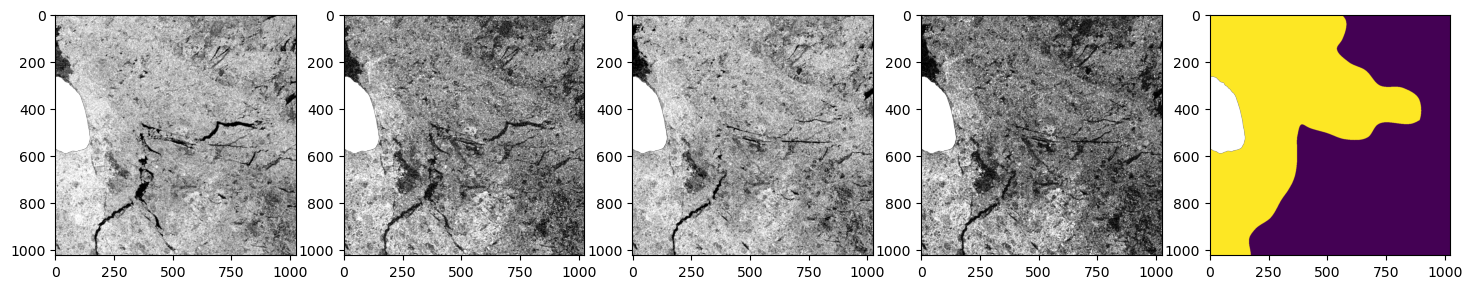

In [7]:
import matplotlib.pyplot as plt
import numpy as np

n = 4
fig, ax = plt.subplots(1, 5, figsize=(18, 5))
ax[0].imshow(inputs[n][0], vmin=np.nanpercentile(inputs[n][0], 1), vmax=np.nanpercentile(inputs[n][0], 99), cmap='gist_gray')
ax[1].imshow(inputs[n][1], vmin=np.nanpercentile(inputs[n][1], 1), vmax=np.nanpercentile(inputs[n][1], 99), cmap='gist_gray')
ax[2].imshow(inputs[n][2], vmin=np.nanpercentile(inputs[n][2], 1), vmax=np.nanpercentile(inputs[n][2], 99), cmap='gist_gray')
ax[3].imshow(inputs[n][3], vmin=np.nanpercentile(inputs[n][3], 1), vmax=np.nanpercentile(inputs[n][3], 99), cmap='gist_gray')
ax[4].imshow(labels[n][0])

### Custom loss to allow zero'ing out loss contributions from invalid pixels

In [8]:
# Custom Weighted Loss

class WeightedBCELoss(nn.Module):
    def __init__(self, class_weights=None):
        super(WeightedBCELoss, self).__init__()
        self.BCELoss = nn.BCEWithLogitsLoss(weight=class_weights, reduction='none')
        
    def forward(self, input: torch.Tensor, target: torch.Tensor, weight_map: torch.Tensor = None):
        loss = self.BCELoss(input, target)

        if weight_map is not None:
            loss *= weight_map

        return loss.mean()

### Trainer class to train the model

In [ ]:
import os
from tqdm import tqdm
import wandb
import json
import datetime

class Trainer():
    def __init__(
            self, 
            model,
            criterion,
            optimizer,
            dataloaders,
            epochs,
            lr_scheduler=None,
            grad_scaler=None,
            resume_from_epoch=0,
            device='cuda',
            save_path=None,
            wandb=False
    ):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.dataloaders = dataloaders
        self.epochs = epochs
        self.lr_scheduler = lr_scheduler
        self.grad_scaler = grad_scaler
        self.resume_from_epoch = resume_from_epoch
        self.device = device
        self.save_path = save_path
        self.wandb = wandb

        if self.resume_from_epoch != 0:
            self._load_checkpoint()

    def fit(self):
        print(f'[{datetime.datetime.now().isoformat(sep= " ", timespec="seconds")}] Training started')

        if self.save_path:
            if not os.path.exists(self.save_path):
                os.makedirs(self.path)

        for epoch in range(self.resume_from_epoch + 1, self.epochs + 1):
            for phase in self.dataloaders.keys():
                self.model.train() if phase == 'train' else self.model.eval()
                dataloader = self.dataloaders[phase]

                self._step(dataloader, phase, epoch)

            if self.lr_scheduler:
                self.lr_scheduler.step()

            if self.save_path:
                self._save_checkpoint(epoch)

    def _step(self, dataloader, phase, epoch):
        running_loss = 0

        for batch in tqdm(dataloader):
            inputs, labels = batch
            inputs = inputs.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                with torch.amp.autocast(self.device, enabled=self.grad_scaler is not None):
                    preds = self.model(inputs)
                    loss = self.criterion(preds, labels) # invlaid mask

                if phase == 'train':
                    if self.grad_scaler:
                        self.grad_scaler.scale(loss).backward()
                        self.grad_scaler.step(self.optimizer)
                        self.grad_scaler.update()
                    else:
                        loss.backward()
                        self.optimizer.step()
            running_loss += loss.item()*labels.size(0)

        if self.save_path:
            logged_loss = running_loss/len(dataloader.dataset)
            self._save_loss_to_json(phase=phase, epoch=epoch, loss=logged_loss)

            if self.wandb:
                wandb.log({f"{phase}_total_loss": logged_loss}, step=epoch)
            
        print(f'[{datetime.datetime.now().isoformat(sep= " ", timespec="seconds")}] Epoch: {epoch}   {phase}_loss: {running_loss/len(dataloader.dataset):.2f}')

    def _save_checkpoint(self, epoch):
        state_dict = {
            'model': self.model.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epoch': epoch
        }
        if self.lr_scheduler:
            state_dict['lr_scheduler'] = self.lr_scheduler.state_dict()
        if self.grad_scaler:
            state_dict['grad_scaler'] = self.grad_scaler.state_dict()

        torch.save(state_dict, os.path.join(self.save_path, f'{epoch}.pt'))

    def _load_checkpoint(self):
        checkpoint = torch.load(self.save_path, f'{self.resume_from_epoch}.pt')
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        if self.lr_scheduler:
            self.lr_scheduler.load_state_dict(checkpoint['lr_scheduler'])
        if self.grad_scaler:
            self.grad_scaler.load_state_dict(checkpoint['grad_scaler'])

    def _save_loss_to_json(self, phase, epoch, loss, prefix=''):
        path = os.path.join(self.save_path, f'{prefix}{phase}_loss_log.json')
        if not os.path.exists(path):
            with open(path, 'w') as f:
                json.dump([], f, indent=2)

        with open(path, 'r') as f:
            loss_log = json.load(f)

        if len(loss_log) >= epoch:
            loss_log[epoch-1] = loss
        else:
            loss_log.append(loss)

        with open(path, 'w') as f:
            json.dump(loss_log, f, indent=2)

In [ ]:
patches = glob.glob('/dmidata/projects/asip-cms/cgf/zarr_files2/*/*.zarr')

train_patches = patches[0:50]
test_patches = patches[0:10]

traindataset = CustomDataset(patch_paths=train_patches, is_train=True)
testdataset = CustomDataset(patch_paths=test_patches, is_train=False)
trainloader = torch.utils.data.DataLoader(traindataset, batch_size=4, num_workers=4, shuffle=True, pin_memory=True)
testloader = torch.utils.data.DataLoader(testdataset, batch_size=1, num_workers=4, shuffle=False, pin_memory=True)

dataloaders = {
    'train': trainloader,
    'val': testloader
}

model = UNet(in_channels=4, out_channels=1, dims=[16, 32, 64, 128, 256, 512])
criterion = WeightedBCELoss()
optimizer = torch.optim.AdamW(params=model.parameters(), lr=3e-4, eps=1e-4)
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 40], gamma=0.1)
grad_scaler = None


device = 'cuda:2'

trainer = Trainer(
    model=model.to(device),
    criterion=criterion,
    optimizer=optimizer,
    dataloaders=dataloaders,
    epochs=50,
    lr_scheduler=lr_scheduler,
    grad_scaler=grad_scaler,
    resume_from_epoch=0,
    device=device,
    save_path=None,
    wandb=False,
)

trainer.fit()

[2026-06-02 12:52:19] Training started


100%|██████████| 13/13 [00:02<00:00,  5.89it/s]


[2026-06-02 12:52:21] Epoch: 1   train_loss: nan


100%|██████████| 10/10 [00:01<00:00,  8.36it/s]


[2026-06-02 12:52:23] Epoch: 1   val_loss: nan


...

[2026-06-02 12:52:36] Epoch: 5   train_loss: nan


100%|██████████| 10/10 [00:01<00:00,  8.98it/s]


[2026-06-02 12:52:37] Epoch: 5   val_loss: nan


  0%|          | 0/13 [00:00<?, ?it/s]


KeyboardInterrupt: 